**What are we doing?**  
We have demographic data for ~900,000 German citizens AND data for existing customers of a mail-order company.  
Our goal is to find `which types of people` are most likely to become customers, so the company can send marketing only to them => saving money.

## Imports

In [165]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.impute import SimpleImputer

## Load Data

In [166]:
azdias = pd.read_csv("Data/Udacity_AZDIAS_Subset.csv",sep=';')
customers = pd.read_csv("Data/Udacity_CUSTOMERS_Subset.csv",sep=';')

In [167]:
azdias.shape

(891221, 85)

In [168]:
customers.shape

(191652, 85)

In [169]:
azdias.head()

,AGER_TYP,ALTERSKATEGORIE_GROB,ANREDE_KZ,CJT_GESAMTTYP,FINANZ_MINIMALIST,FINANZ_SPARER,FINANZ_VORSORGER,FINANZ_ANLEGER,FINANZ_UNAUFFAELLIGER,FINANZ_HAUSBAUER,...,PLZ8_ANTG1,PLZ8_ANTG2,PLZ8_ANTG3,PLZ8_ANTG4,PLZ8_BAUMAX,PLZ8_HHZ,PLZ8_GBZ,ARBEIT,ORTSGR_KLS9,RELAT_AB
0,-1,2,1,2.0,3,4,3,5,5,3,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,-1,1,2,5.0,1,5,2,5,4,5,...,2.0,3.0,2.0,1.0,1.0,5.0,4.0,3.0,5.0,4.0
2,-1,3,2,3.0,1,4,1,2,3,5,...,3.0,3.0,1.0,0.0,1.0,4.0,4.0,3.0,5.0,2.0
3,2,4,2,2.0,4,2,5,2,1,2,...,2.0,2.0,2.0,0.0,1.0,3.0,4.0,2.0,3.0,3.0
4,-1,3,1,5.0,4,3,4,1,3,2,...,2.0,4.0,2.0,1.0,2.0,3.0,3.0,4.0,6.0,5.0


In [170]:
print(azdias.dtypes.value_counts())

float64    49
int64      32
object      4
Name: count, dtype: int64


In [171]:
print('Null Count :',azdias.isnull().sum().sum())

Null Count : 4896838


## Exploring Data

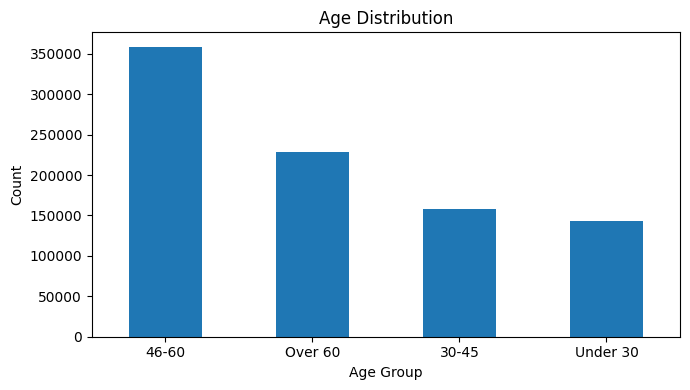

In [172]:
age_labels = {1: 'Under 30', 2: '30-45', 3: '46-60', 4: 'Over 60'}

age_counts = azdias['ALTERSKATEGORIE_GROB'].replace(-1, np.nan).dropna()
age_counts = age_counts.map(age_labels).value_counts()

plt.figure(figsize=(7, 4))
age_counts.plot(kind='bar')
plt.title('Age Distribution')
plt.xlabel('Age Group')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

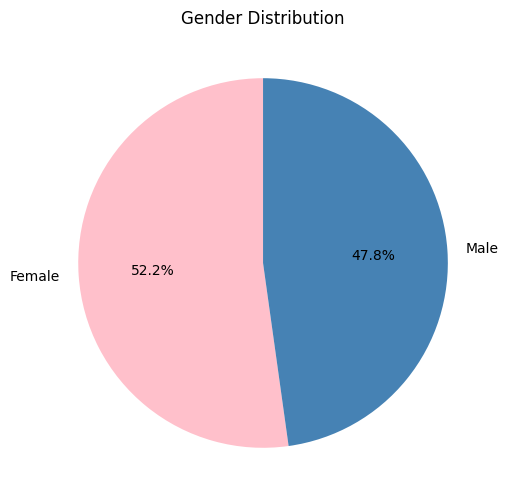

In [173]:
gender_labels = {1: 'Male', 2: 'Female'}

gender_counts = azdias['ANREDE_KZ'].replace([-1,0], np.nan).dropna()
gender_counts = gender_counts.map(gender_labels).value_counts()

plt.figure(figsize=(6, 6))
plt.pie(gender_counts,labels=gender_counts.index,autopct='%1.1f%%',startangle=90,colors=['pink','steelblue'])
plt.title('Gender Distribution')
plt.show()

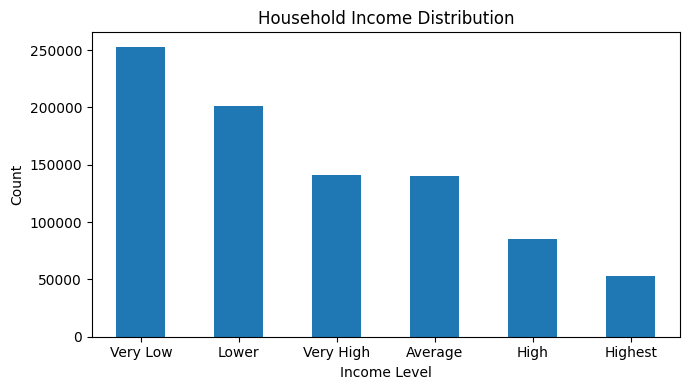

In [174]:
income_labels = {1:'Highest', 2:'Very High', 3:'High', 4:'Average', 5:'Lower', 6:'Very Low'}

income_counts = azdias['HH_EINKOMMEN_SCORE'].replace([-1,0], np.nan).dropna()
income_counts = income_counts.map(income_labels).value_counts()

plt.figure(figsize=(7, 4))
income_counts.plot(kind='bar')
plt.title('Household Income Distribution')
plt.xlabel('Income Level')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Data Cleaning

- we can find that the data has `unknown` data as **-1 , 0 , 9** not as **NaN**.
  So we need to replace it with `NaN`
- Drop columns which have >30% missing (`mostly missing`)
- Drop rows which have too missing values
- Fill remaining with **median**



In [175]:
UNKNOWN_CODES = {
    'AGER_TYP'             : [-1],
    'ALTERSKATEGORIE_GROB' : [-1],
    'ANREDE_KZ'            : [-1],
    'FINANZ_MINIMALIST'    : [-1],
    'FINANZ_SPARER'        : [-1],
    'FINANZ_VORSORGER'     : [-1],
    'FINANZ_ANLEGER'       : [-1],
    'FINANZ_UNAUFFAELLIGER': [-1],
    'FINANZ_HAUSBAUER'     : [-1],
    'FINANZTYP'            : [-1],
    'GEBURTSJAHR'          : [0],
    'HEALTH_TYP'           : [-1],
    'NATIONALITAET_KZ'     : [-1],
    'PRAEGENDE_JUGENDJAHRE': [-1, 0],
    'SHOPPER_TYP'          : [-1],
    'SEMIO_SOZ'            : [-1, 9],
    'SEMIO_FAM'            : [-1, 9],
    'SEMIO_REL'            : [-1, 9],
    'SEMIO_MAT'            : [-1, 9],
    'SEMIO_VERT'           : [-1, 9],
    'SEMIO_LUST'           : [-1, 9],
    'SEMIO_ERL'            : [-1, 9],
    'SEMIO_KULT'           : [-1, 9],
    'SEMIO_RAT'            : [-1, 9],
    'SEMIO_KRIT'           : [-1, 9],
    'SEMIO_DOM'            : [-1, 9],
    'SEMIO_KAEM'           : [-1, 9],
    'SEMIO_PFLICHT'        : [-1, 9],
    'SEMIO_TRADV'          : [-1, 9],
    'VERS_TYP'             : [-1],
    'ZABEOTYP'             : [-1, 9],
    'ALTER_HH'             : [0],
    'HH_EINKOMMEN_SCORE'   : [-1],
    'KK_KUNDENTYP'         : [-1],
    'W_KEIT_KIND_HH'       : [-1],
    'WOHNDAUER_2008'       : [-1],
    'ANZ_HAUSHALTE_AKTIV'  : [0],
    'GEBAEUDETYP'          : [-1],
    'MIN_GEBAEUDEJAHR'     : [0],
    'OST_WEST_KZ'          : [-1],
    'WOHNLAGE'             : [-1],
    'CAMEO_DEUG_2015'      : [-1, 'X'],
    'CAMEO_INTL_2015'      : [-1, 'XX'],
    'KBA05_ANTG1'          : [-1],
    'KBA05_ANTG2'          : [-1],
    'KBA05_ANTG3'          : [-1],
    'KBA05_ANTG4'          : [-1],
    'KBA05_BAUMAX'         : [-1, 0],
    'KBA05_GBZ'            : [-1, 0],
    'BALLRAUM'             : [-1],
    'EWDICHTE'             : [-1],
    'INNENSTADT'           : [-1],
    'KKK'                  : [-1, 0],
    'REGIOTYP'             : [-1, 0],
    'PLZ8_ANTG1'           : [-1],
    'PLZ8_ANTG2'           : [-1],
    'PLZ8_ANTG3'           : [-1],
    'PLZ8_ANTG4'           : [-1],
    'PLZ8_BAUMAX'          : [-1, 0],
    'PLZ8_HHZ'             : [-1],
    'PLZ8_GBZ'             : [-1],
    'ARBEIT'               : [-1, 9],
    'ORTSGR_KLS9'          : [-1],
    'RELAT_AB'             : [-1, 9],
}

print(f'Unknown-code map ready for {len(UNKNOWN_CODES)} columns.')

Unknown-code map ready for 64 columns.


In [176]:
def clean_data(df,unkown_codes, drop_cols=None, row_thresh=None):
    df = df.copy()

    # Replace "unkown" with NaN
    for col , vals in unkown_codes.items():
        if col in df.columns:
            df[col] = df[col].replace(vals , np.nan)

    # Drop Cols with >30% missing
    if drop_cols is None:
        drop_cols = df.columns[df.isnull().mean() > 0.30].tolist()
        drop_cols += ['CAMEO_DEU_2015']  # string column ==> not needed
    df.drop(columns=[c for c in drop_cols if c in df.columns], inplace=True)

    # Drop Rows 
    if row_thresh is None:
        row_thresh = df.isnull().sum(axis=1).quantile(0.95)
    df = df[df.isnull().sum(axis=1) <= row_thresh]

    # Encode the only text column
    if 'OST_WEST_KZ' in df.columns:
        df['OST_WEST_KZ'] = df['OST_WEST_KZ'].map({'O': 0, 'W': 1})

    # Fill NaN with median
    imputer = SimpleImputer(strategy='median')
    imputer.fit(azdias)
    customers = imputer.transform(customers)

    return df , drop_cols ,row_thresh

In [177]:
print('Before cleaning:')
print(f'General population : {azdias.shape}')
print(f'Customers          : {customers.shape}')

Before cleaning:
General population : (891221, 85)
Customers          : (191652, 85)


In [178]:
# Clean population first ==> set our thresholds
azdias_clean, dropped_cols, row_thresh = clean_data(azdias, UNKNOWN_CODES)

# Clean customers using the same thresholds
customers_clean, _, _ = clean_data(
    customers,
    UNKNOWN_CODES,
    drop_cols=dropped_cols,
    row_thresh=row_thresh
)

print('After cleaning:')
print(f'General population : {azdias_clean.shape}')
print(f'Customers          : {customers_clean.shape}')
print(f'Columns dropped    : {len(dropped_cols)}')

MemoryError: Unable to allocate 218. MiB for an array with shape (32, 891221) and data type object

## Feature Scalling


In [ ]:
scaler = StandardScaler()
azdias_scaled = scaler.fit_transform(azdias_clean)
customers_scaled = scaler.transform(customers_clean) # only transform ==> because we only fit on population
print('Done Scalling')

Done Scalling


## Appling PCA   
* Dimentionality Reduction => `Extracting important features`

In [ ]:
from sklearn.decomposition import PCA
pca = PCA()
azdias_pca = pca.fit_transform(azdias_scaled)

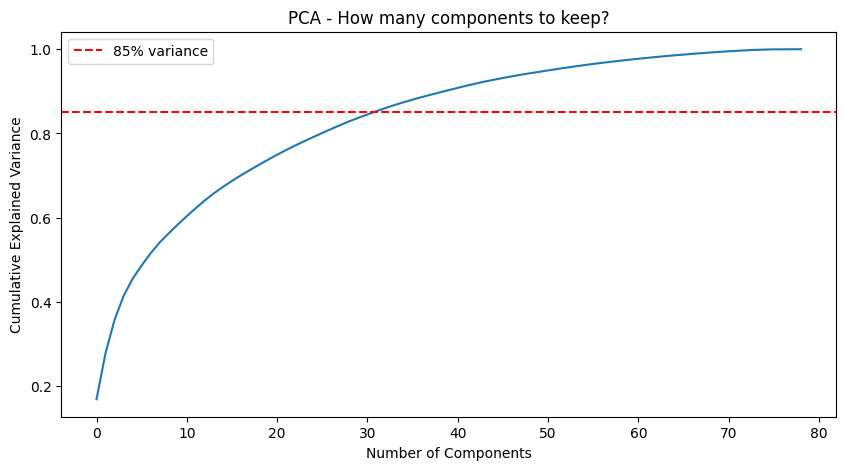

In [ ]:
# Explained Variance Plot (Scree Plot)
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(10, 5))
plt.plot(cumulative_variance)
plt.axhline(y=0.85, color='r', linestyle='--', label='85% variance')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA - How many components to keep?')
plt.legend()
plt.show()


In [ ]:
# Number of components that explains 85% of variance
n_components = np.argmax(cumulative_variance >= 0.85) + 1
print(f'Components needed: {n_components}')

Components needed: 32


In [ ]:
# Fitting the PCA with the best number of components
pca = PCA(n_components=n_components)
azdias_pca = pca.fit_transform(azdias_scaled)
customers_pca = pca.transform(customers_scaled)


In [ ]:
def plot_pca_weights(df, pca, component_num, n_features=5):
    
    weights = pd.DataFrame(
        pca.components_,
        columns=df.columns
    ).iloc[component_num - 1]
    
    # أعلى positive
    top_positive = weights.sort_values(ascending=False).head(n_features)
    
    # أعلى negative
    top_negative = weights.sort_values().head(n_features)
    
    # دمجهم
    top_features = pd.concat([top_positive, top_negative])
    
    # رسم
    plt.figure(figsize=(10,5))
    colors = ['green' if val > 0 else 'red' for val in top_features]
    
    top_features.plot(kind='bar', color=colors)
    
    plt.title(f'PCA Component {component_num} - Top Features')
    plt.ylabel("Weight")
    plt.xticks(rotation=45, ha='right')
    plt.axhline(0, color='black')
    plt.tight_layout()
    plt.show()

## K_means Clustring   
 * Dividing Azdias to clusters 

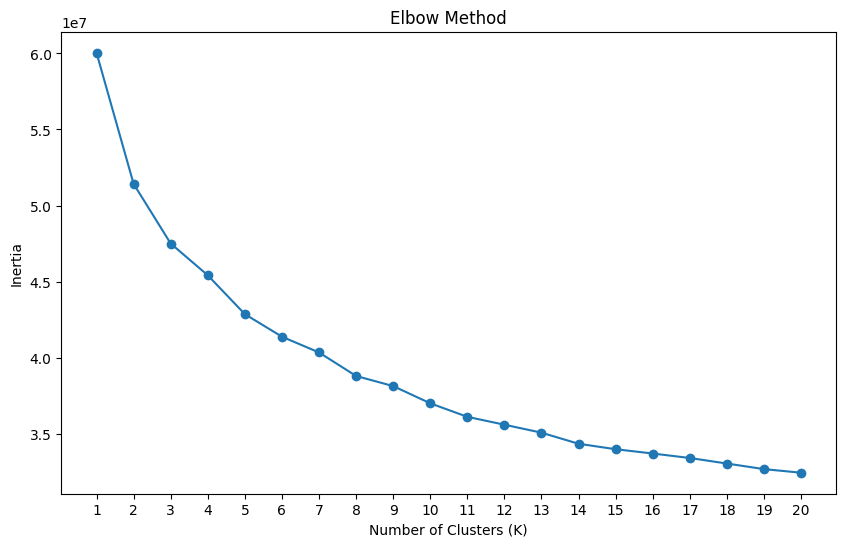

In [ ]:
scores = []
k_range = range(1,21) 

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42).fit(azdias_pca)
    scores.append(abs(kmeans.score(azdias_pca)))
    
plt.figure(figsize=(10, 6))
plt.xticks(k_range)
plt.plot(k_range, scores, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

## KneeLocator   
* Auto detection for the elbow 

Suggested K = 8


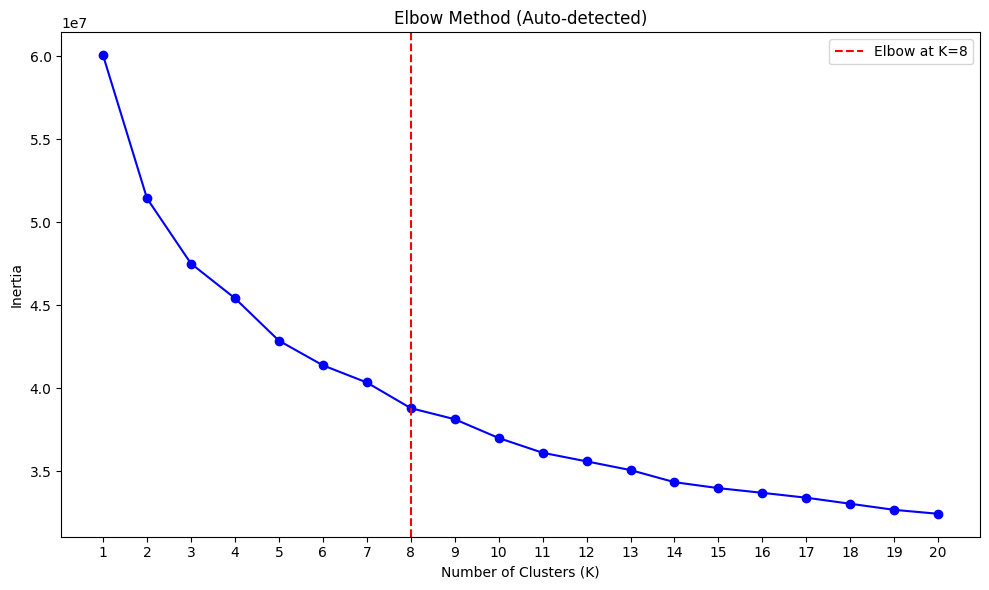

In [ ]:
from kneed import KneeLocator

kneedle = KneeLocator(list(k_range), scores,curve='convex', direction='decreasing')

print(f'Suggested K = {kneedle.knee}')

plt.figure(figsize=(10, 6))
plt.xticks(k_range)
plt.plot(k_range, scores, 'bo-')
plt.axvline(x=kneedle.knee, color='red', linestyle='--',
            label=f'Elbow at K={kneedle.knee}')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method (Auto-detected)')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
optimal_k = 8  

kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
azdias_clusters = kmeans.fit_predict(azdias_pca)
customers_clusters = kmeans.predict(customers_pca)  

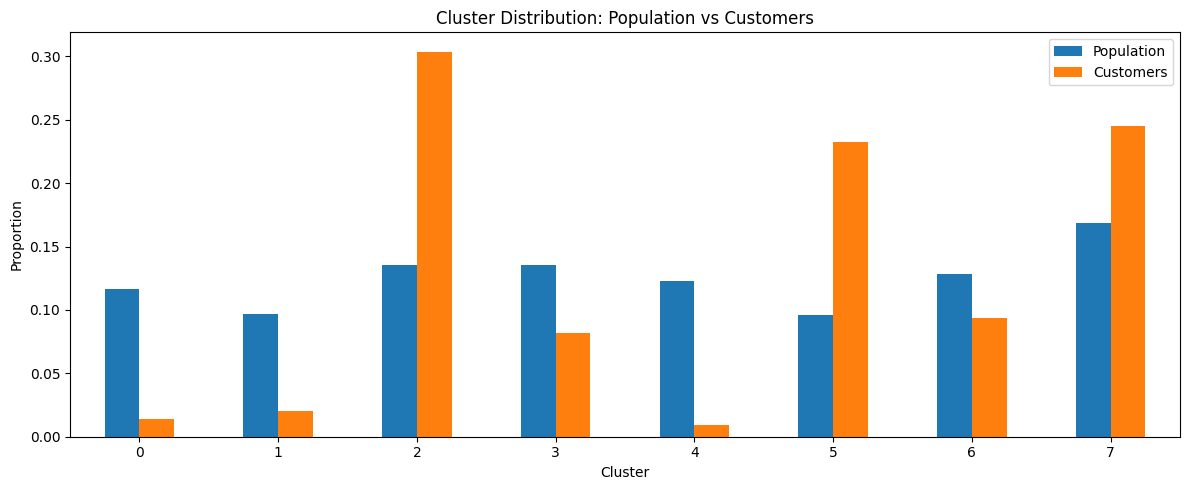

In [ ]:
pop_counts = pd.Series(azdias_clusters).value_counts(normalize=True).sort_index()
cust_counts = pd.Series(customers_clusters).value_counts(normalize=True).sort_index()

comparison = pd.DataFrame({
    'Population': pop_counts,
    'Customers': cust_counts
}).fillna(0)

comparison.plot(kind='bar', figsize=(12, 5))
plt.title('Cluster Distribution: Population vs Customers')
plt.xlabel('Cluster')
plt.ylabel('Proportion')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
comparison['ratio'] = comparison['Customers'] / (comparison['Population'] + 1e-9)
comparison_sorted = comparison.sort_values('ratio', ascending=False)

print("OVER-represented clusters (TARGET customers):")
print(comparison_sorted.head(3))

print("\nUNDER-represented clusters (avoid):")
print(comparison_sorted.tail(3))



OVER-represented clusters (TARGET customers):
   Population  Customers     ratio
5    0.095993   0.232129  2.418183
2    0.135445   0.303791  2.242911
7    0.168694   0.244982  1.452231

UNDER-represented clusters (avoid):
   Population  Customers     ratio
1    0.096862   0.020086  0.207372
0    0.116492   0.013819  0.118626
4    0.123162   0.009576  0.077752


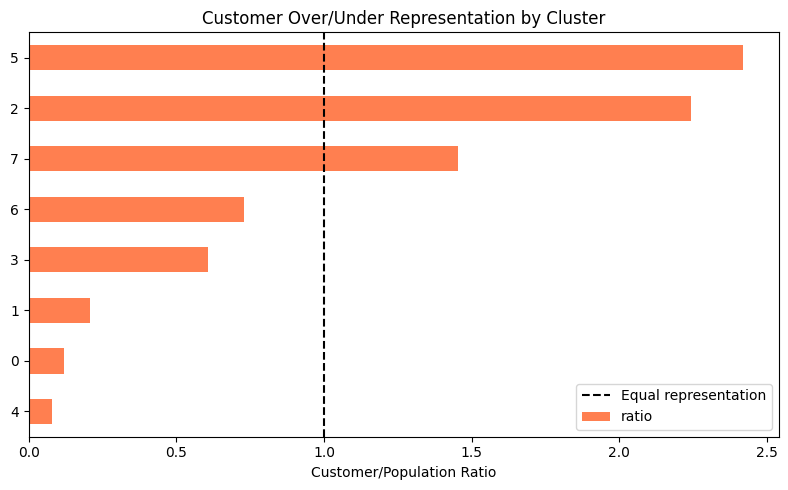

In [ ]:
# Visualization
comparison['ratio'].sort_values().plot(
    kind='barh', figsize=(8, 5), color='coral'
)
plt.axvline(x=1, color='black', linestyle='--', label='Equal representation')
plt.title('Customer Over/Under Representation by Cluster')
plt.xlabel('Customer/Population Ratio')
plt.legend()
plt.tight_layout()
plt.show()

## Customer Profiling  
* selecting the target population   
* adding persona for each target cluster

In [ ]:
# Adding a new column of clusters
azdias_profiling = azdias_clean.copy()
azdias_profiling['Cluster'] = azdias_clusters

# The average for each cluster
cluster_profiles = azdias_profiling.groupby('Cluster').mean()
print(cluster_profiles.shape)     # (n_clusters, n_features)

(8, 79)


In [ ]:
# Selection the top target and non target clusters
target_clusters     = comparison_sorted.head(3).index.tolist()
non_target_clusters = comparison_sorted.tail(3).index.tolist()

print("Target clusters    :", target_clusters)
print("Non-target clusters:", non_target_clusters)

# 
target_profile     = cluster_profiles.loc[target_clusters].mean()
non_target_profile = cluster_profiles.loc[non_target_clusters].mean()

Target clusters    : [5, 2, 7]
Non-target clusters: [1, 0, 4]


In [ ]:
# key_features = [
#     'ALTERSKATEGORIE_GROB',  # Age group
#     'ANREDE_KZ',             # Gender
#     'HH_EINKOMMEN_SCORE',    # Household income
#     'FINANZ_MINIMALIST',     # Financial type
#     'SEMIO_SOZ',             # Social personality
#     'WOHNLAGE',              # Residential area quality
# ]
key_features = [
    'CAMEO_INTL_2015',
    'HH_EINKOMMEN_SCORE',
    'KBA13_ANZAHL_PKW',
    'FINANZ_MINIMALIST',
    'FINANZ_VORSORGER',
    'SEMIO_LUST',
    'LP_STATUS_GROB'
]
comparison_profile = pd.DataFrame({
    'Target'    : target_profile[key_features],
    'Non-Target': non_target_profile[key_features],
})

print(comparison_profile)

                        Target  Non-Target
CAMEO_INTL_2015      30.911673   36.651943
HH_EINKOMMEN_SCORE    2.944735    4.696273
KBA13_ANZAHL_PKW    639.335737  614.907380
FINANZ_MINIMALIST     3.863733    2.152723
FINANZ_VORSORGER      3.766144    2.172614
SEMIO_LUST            5.032332    2.994442
LP_STATUS_GROB        3.314097    1.973137


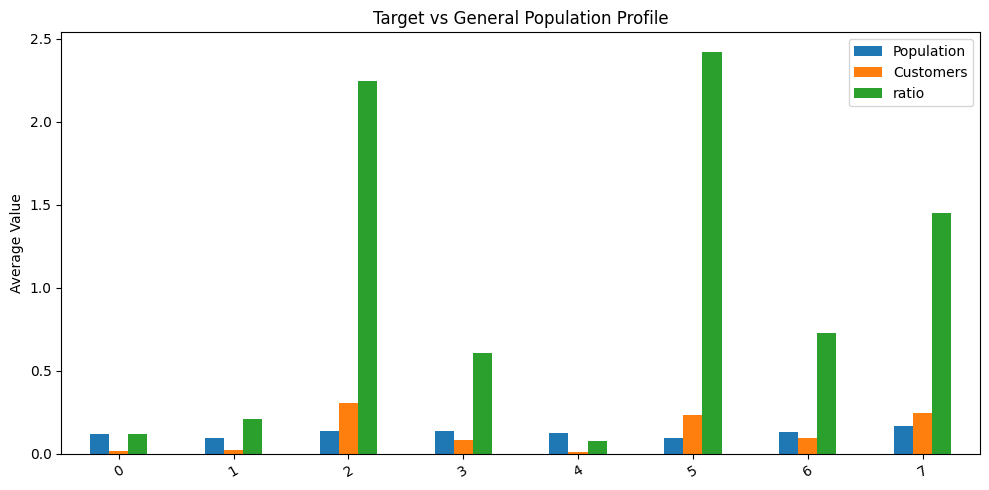

In [ ]:
# comparison_profile.plot(kind='bar', figsize=(10, 5), color=['green', 'red'])
# plt.title('Target vs Non-Target Customer Profile')
# plt.ylabel('Mean Value')
# plt.xticks(rotation=30, ha='right')
# plt.legend()
# plt.tight_layout()
# plt.show()
comparison.plot(kind='bar', figsize=(10,5))
plt.title("Target vs General Population Profile")
plt.ylabel("Average Value")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [ ]:
# Extracting the features that differs between customers and not customers
diff = customers_clean.mean() - azdias_clean.mean()

top_features = (diff.abs()
                .sort_values(ascending=False)
                .head(10)
                .index.tolist())

print("Top 10 most distinguishing features:")
for f in top_features:
    direction = "↑ Higher in customers" if diff[f] > 0 else "↓ Lower in customers"
    print(f"  {f:30s}  {direction}  (diff={diff[f]:+.3f})")

Top 10 most distinguishing features:
  KBA13_ANZAHL_PKW                ↑ Higher in customers  (diff=+36.067)
  CAMEO_INTL_2015                 ↓ Lower in customers  (diff=-8.164)
  ANZ_HAUSHALTE_AKTIV             ↓ Lower in customers  (diff=-3.922)
  PRAEGENDE_JUGENDJAHRE           ↓ Lower in customers  (diff=-3.733)
  LP_LEBENSPHASE_FEIN             ↑ Higher in customers  (diff=+3.542)
  LP_STATUS_FEIN                  ↑ Higher in customers  (diff=+1.906)
  CAMEO_DEUG_2015                 ↓ Lower in customers  (diff=-1.332)
  HH_EINKOMMEN_SCORE              ↓ Lower in customers  (diff=-1.296)
  GFK_URLAUBERTYP                 ↓ Lower in customers  (diff=-1.073)
  SEMIO_LUST                      ↑ Higher in customers  (diff=+1.008)


In [ ]:
# Mapping the values of the top distinguishing features columns
def decode_feature(col, val):
 
    v = round(val)
    maps = {
        'ALTERSKATEGORIE_GROB': {
            1:'Under 30', 2:'30-45', 3:'46-60', 4:'Over 60'
        },
        'ANREDE_KZ': {
            1:'Male', 2:'Female'
        },
        'HH_EINKOMMEN_SCORE': {
            1:'Highest Income', 2:'Very High Income', 3:'High Income',
            4:'Average Income', 5:'Lower Income', 6:'Very Low Income'
        },
        'FINANZ_MINIMALIST': {
            1:'Very High (Low Financial Interest)',
            2:'High', 3:'Average', 4:'Low', 5:'Very Low'
        },
        'LP_STATUS_GROB': {
            1:'Low-Income Earner', 2:'Average Earner',
            3:'Independent', 4:'Houseowner', 5:'Top Earner'
        },
        'LP_FAMILIE_GROB': {
            0:'Unknown', 1:'Single', 2:'Couple',
            3:'Single Parent', 4:'Family', 5:'Multiperson Household'
        },
        'SHOPPER_TYP': {
            0:'Unknown', 1:'Determined Shopper',
            2:'Searching Shopper', 3:'Bargain-Hunting Shopper',
            4:'Stimulus-Driven Shopper'
        },
       
        'SEMIO_LUST': {
            1:'Very Sensual/Fun', 2:'Sensual', 3:'Average',
            4:'Less', 5:'Not Sensual', 6:'Very Not', 7:'Extremely Not'
        },
    }

    if col in maps:
        return maps[col].get(v, f"Value={v}")
    else:
        return f"{val:.2f}"   


In [ ]:
# Building a persona for each cluster
PERSONA_FEATURES = [
    # Demographics
    ('ALTERSKATEGORIE_GROB', 'Age Group'),
    ('ANREDE_KZ',            'Gender'),
    ('LP_STATUS_GROB',       'Social Status'),
    ('LP_FAMILIE_GROB',      'Family Type'),

    # Financial
    ('HH_EINKOMMEN_SCORE',   'Household Income'),
    ('FINANZ_MINIMALIST',    'Financial Minimalism'),

    # Personality
    ('SEMIO_LUST',  'Personality Typology'),
]

personas = {}
for cluster in cluster_profiles.index:
    data = cluster_profiles.loc[cluster]
    persona = {}
    for col, label in PERSONA_FEATURES:
        if col in data.index:
            persona[label] = decode_feature(col, data[col])
    personas[cluster] = persona

In [ ]:
# Printing the target and non target personas
target_clusters     = comparison_sorted.head(3).index.tolist()
non_target_clusters = comparison_sorted.tail(2).index.tolist()

print("TARGET CUSTOMERS — WHO TO SEND MAIL TO")

for c in target_clusters:
    ratio = comparison.loc[c, 'ratio']
    print(f"\n{'='*45}")
    print(f"  CLUSTER {c}  |  Customer/Population Ratio: {ratio:.2f}x")
    print(f"{'='*45}")
    for k, v in personas[c].items():
        print(f"  {k:<25} {v}")

print("NON-TARGET — WHO TO AVOID")

for c in non_target_clusters:
    ratio = comparison.loc[c, 'ratio']
    print(f"\n{'='*45}")
    print(f"  CLUSTER {c}  |  Customer/Population Ratio: {ratio:.2f}x")
    print(f"{'='*45}")
    for k, v in personas[c].items():
        print(f"  {k:<25} {v}")

TARGET CUSTOMERS — WHO TO SEND MAIL TO

  CLUSTER 5  |  Customer/Population Ratio: 2.42x
  Age Group                 30-45
  Gender                    Female
  Social Status             Average Earner
  Family Type               Single
  Household Income          Very High Income
  Financial Minimalism      Average
  Personality Typology      Not Sensual

  CLUSTER 2  |  Customer/Population Ratio: 2.24x
  Age Group                 46-60
  Gender                    Female
  Social Status             Houseowner
  Family Type               Multiperson Household
  Household Income          High Income
  Financial Minimalism      Low
  Personality Typology      Not Sensual

  CLUSTER 7  |  Customer/Population Ratio: 1.45x
  Age Group                 Over 60
  Gender                    Male
  Social Status             Houseowner
  Family Type               Single
  Household Income          High Income
  Financial Minimalism      Low
  Personality Typology      Not Sensual
NON-TARGET — WHO T